# SHAP Explainability with XGBoost — Bike Sharing Dataset

This exercise trains an `XGBRegressor` to predict hourly bike rental counts (UCI Bike Sharing dataset), then uses **SHAP** (SHapley Additive exPlanations) to explain the model's predictions:

1. Download and load the dataset.
2. Train an XGBoost regression pipeline (scaling + model) with cross-validation.
3. Compute SHAP values and visualize global feature importance (summary plot), and per-feature effects and interactions (dependence plots) for the top 3 features.

## 1. Imports

In [13]:
import numpy as np
import pandas as pd
import os
import requests
import zipfile
import io
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb

## 2. Data Loading

Downloads and extracts the [UCI Bike Sharing Dataset](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip) (hourly data), then selects the feature columns and the target (`cnt`, the total rental count).

In [8]:
def load_bike_sharing_data() -> tuple[pd.DataFrame, pd.Series, list[str]]:
    """
    Download, unzip and load the sharing bike dataset.

    Returns:
        A tuple of (feature matrix X, target series y, list of feature names).
    """
    print("Step 1: Preparing dataset")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip"

    if not os.path.exists('data'):
        os.makedirs('data')

    csv_path = 'data/hour.csv'

    if not os.path.exists(csv_path):
        print("   - Downloading dataset...")
        response = requests.get(url, stream=True)
        if response.status_code == 200:
            with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
                zip_ref.extractall('data')
            print("   - Dataset extracted successfully")
        else:
            raise Exception(f"Failed to download dataset. Status code: {response.status_code}")

    print("   - Loading dataset...")
    df = pd.read_csv(csv_path)

    features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
               'workingday', 'weathersit', 'temp', 'atemp',
               'hum', 'windspeed']

    X = df[features]
    y = df['cnt']

    print(f"   - Dataset loaded. Shape: {X.shape}")

    return X, y, features

## 3. Model Training

Builds a `Pipeline` (`StandardScaler` + `XGBRegressor`), fits it on an 80/20 train/test split, reports 5-fold cross-validation RMSE on the training set, evaluates RMSE and R² on the held-out test set, and prints the model's built-in feature importances.

In [9]:
def train_xgboost_model(
    X: pd.DataFrame, y: pd.Series, features: list[str]
) -> Pipeline:
    """
    Train a XGBoost model for bike sharing predictions.
    Includes preprocessing, training, cross-validation and evaluation.

    Args:
        X: Feature matrix.
        y: Target values (rental counts).
        features: Names of the columns in X, used to report feature importance.

    Returns:
        The fitted scikit-learn Pipeline (scaler + XGBoost regressor).
    """
    # train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Preprocessing pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgboost', xgb.XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42,
            n_jobs=-1
        ))
    ])

    # Training the model
    print("Training model...")
    pipeline.fit(X_train, y_train)

    # Cross-validation on training set
    print("\nCross-validation scores:")
    cv_scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=5, scoring='neg_root_mean_squared_error'
    )
    print(f"RMSE CV scores: {-cv_scores}")
    print(f"Average RMSE CV: {-cv_scores.mean():.2f} (±{cv_scores.std()*2:.2f})")

    # Evaluation on test set
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("\nEvaluation on test set:")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.3f}")

    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': pipeline.named_steps['xgboost'].feature_importances_
    })
    feature_importance = feature_importance.sort_values('importance', ascending=False)

    print("\nFeature Importance:")
    print(feature_importance)

    return pipeline

## 4. Run the Pipeline

Load the dataset and train the model.

In [10]:
X, y, features = load_bike_sharing_data()
model = train_xgboost_model(X, y, features)

Step 1: Preparing dataset
   - Loading dataset...
   - Dataset loaded. Shape: (17379, 12)
Training model...

Cross-validation scores:
RMSE CV scores: [44.85935211 48.14560318 48.20118332 46.72877121 46.10100555]
Average RMSE CV: 46.81 (±2.54)

Evaluation on test set:
RMSE: 44.72
R2 Score: 0.937

Feature Importance:
       feature  importance
3           hr    0.232500
1           yr    0.188196
6   workingday    0.156232
8         temp    0.133198
9        atemp    0.087516
0       season    0.085011
7   weathersit    0.052407
10         hum    0.022243
2         mnth    0.018287
5      weekday    0.012198
4      holiday    0.008101
11   windspeed    0.004111


## 5. Model Explainability with SHAP

`shap.TreeExplainer` needs direct access to the underlying booster rather than the full `Pipeline`, so we first extract the fitted `XGBRegressor` from the pipeline's steps.

In [11]:
def get_model_from_pipeline(model: Pipeline | xgb.XGBRegressor) -> xgb.XGBRegressor:
    """
    Extract XGBoost model from the pipeline.

    Args:
        model: Either a fitted Pipeline containing an 'xgboost' step, or an
            XGBRegressor instance directly.

    Returns:
        The fitted XGBRegressor.
    """
    if isinstance(model, Pipeline):
        return model.named_steps['xgboost']
    return model

### SHAP Analysis

Computes SHAP values on a 1000-row sample (for speed) and plots:
- A **summary plot** — global feature importance and the direction of each feature's effect.
- For each of the **top 3 features** by mean absolute SHAP value: a **dependence plot** showing how the feature's value affects its SHAP value, and an **interaction plot** against the single strongest feature to reveal interaction effects.

Computing SHAP values...


<Figure size 640x480 with 0 Axes>

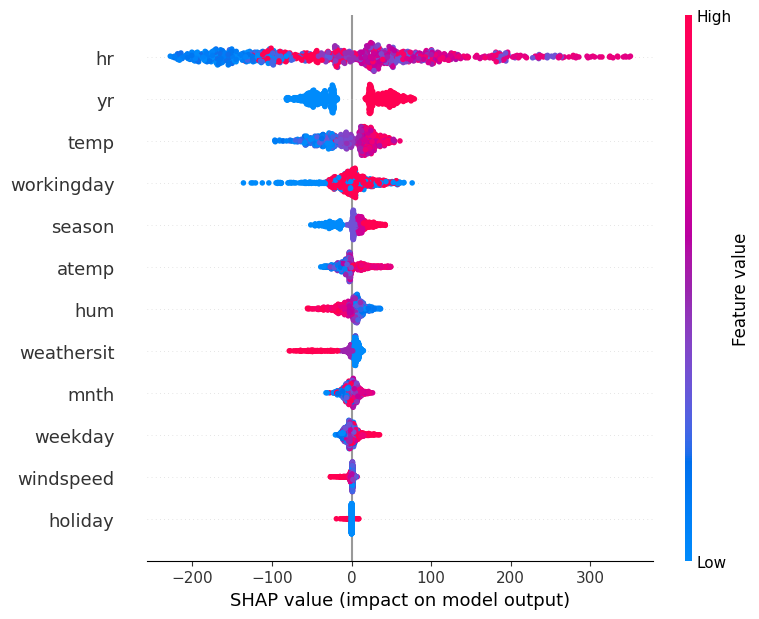


Detailed analysis of the top 3 features:
----------------------------------------

Analyzing: hr


<Figure size 1200x600 with 0 Axes>

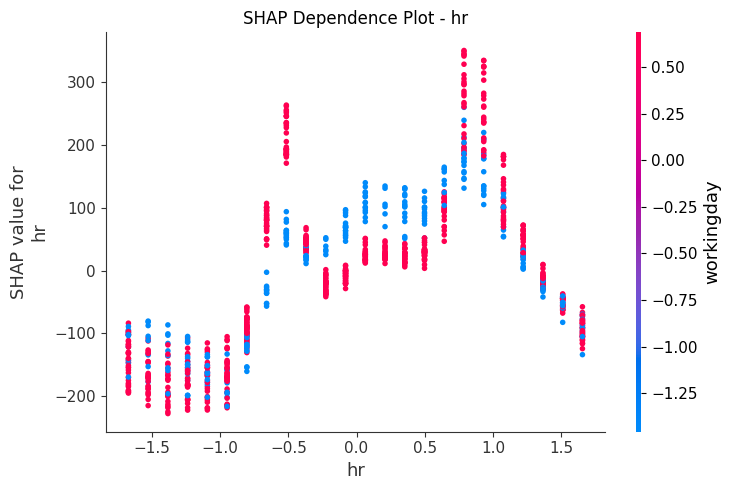

<Figure size 1200x600 with 0 Axes>

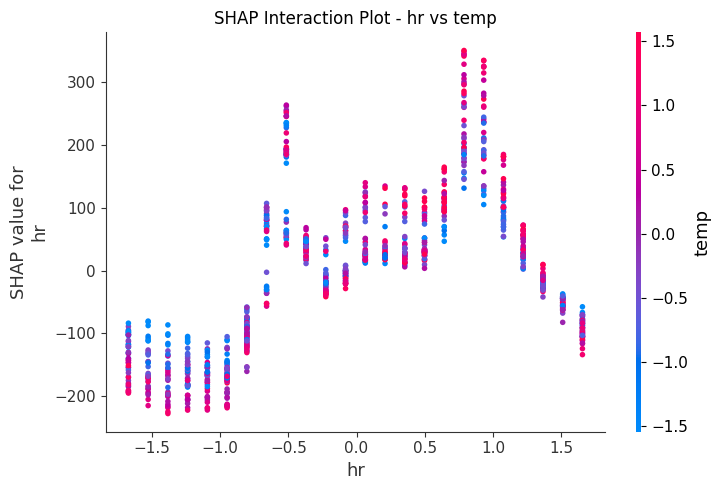


Analyzing: yr


<Figure size 1200x600 with 0 Axes>

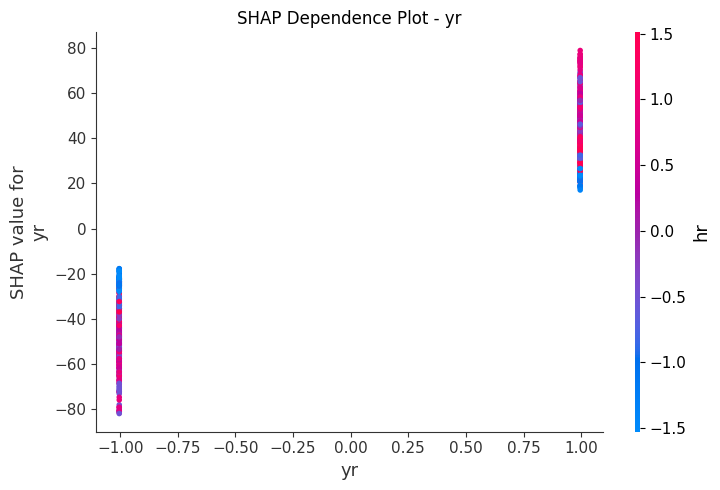

<Figure size 1200x600 with 0 Axes>

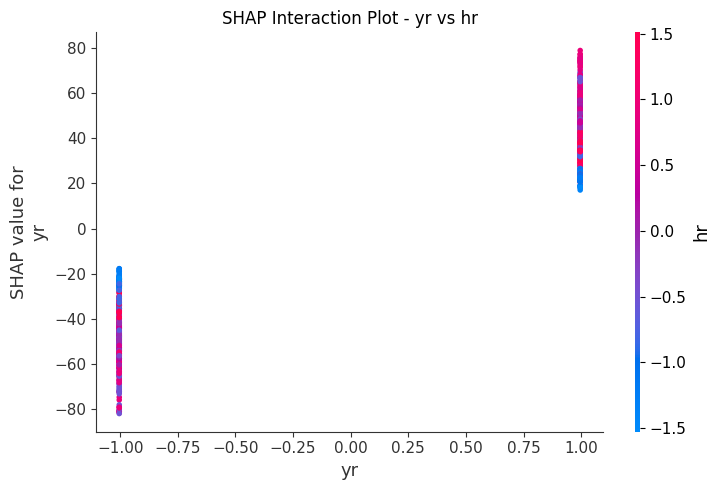


Analyzing: temp


<Figure size 1200x600 with 0 Axes>

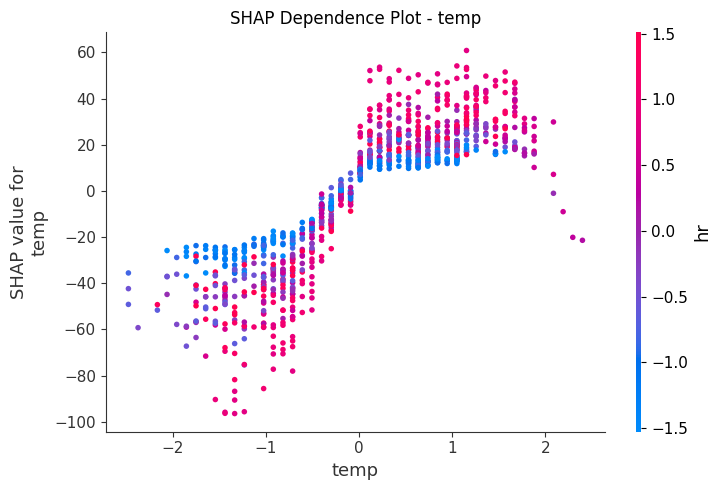

<Figure size 1200x600 with 0 Axes>

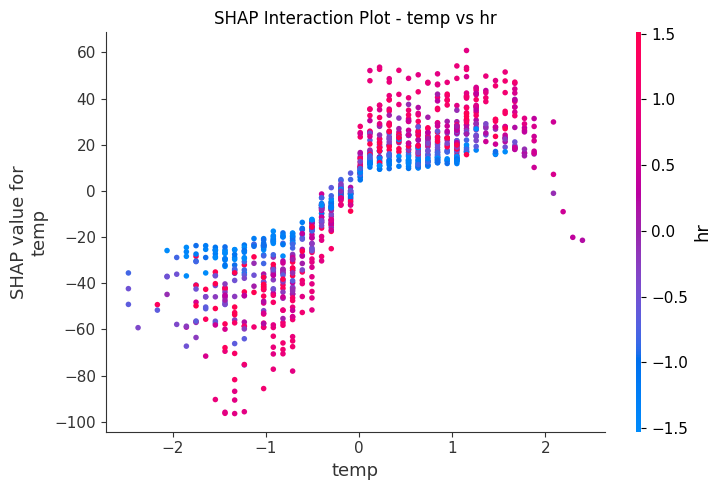

In [12]:
def analyze_model(
    model: Pipeline | xgb.XGBRegressor, X: pd.DataFrame, features: list[str]
) -> None:
    """
    Analyze the model using SHAP values.

    Args:
        model: Fitted Pipeline (scaler + xgboost step) or XGBRegressor directly.
        X: Feature matrix to explain (before preprocessing).
        features: Names of the columns in X.
    """
    # Extract the model from the pipeline if needed
    tree_model = get_model_from_pipeline(model)

    # If we have a pipeline, we need to transform the data
    if isinstance(model, Pipeline):
        # Take all pipeline steps except the last one (the model)
        preprocessing_steps = Pipeline(model.steps[:-1])
        X_transformed = preprocessing_steps.transform(X)
        X_for_analysis = pd.DataFrame(X_transformed, columns=features)
    else:
        X_for_analysis = X

    # Compute SHAP values
    print("Computing SHAP values...")
    explainer = shap.TreeExplainer(tree_model)
    # Take a sample of 1000 observations to speed up the analysis
    X_sample = X_for_analysis.sample(n=1000, random_state=42)
    shap_values = explainer.shap_values(X_sample)

    plt.clf()  # Clear the current figure
    plt.figure(figsize=(12, 6))
    shap.summary_plot(
        shap_values,
        X_sample,
        feature_names=features,
        show=False,
    )
    plt.tight_layout()
    plt.show()


    # Find the most important features
    feature_importance = np.abs(shap_values).mean(0)
    top_features_idx = np.argsort(-feature_importance)[:3]
    top_features = [features[i] for i in top_features_idx]

    print("\nDetailed analysis of the top 3 features:")
    print("----------------------------------------")
    for feature in top_features:
        print(f"\nAnalyzing: {feature}")

        # SHAP Dependence plot
        plt.figure(figsize=(12, 6))
        shap.dependence_plot(
            features.index(feature),
            shap_values,
            X_sample,
            feature_names=features,
            show=False
        )
        plt.title(f"SHAP Dependence Plot - {feature}")
        plt.tight_layout()
        plt.show()

        # SHAP Interaction plot
        plt.figure(figsize=(12, 6))
        interaction_feature = top_features[0] if feature != top_features[0] else top_features[2]
        shap.dependence_plot(
            features.index(feature),
            shap_values,
            X_sample,
            feature_names=features,
            interaction_index=features.index(interaction_feature),
            show=False
        )
        plt.title(f"SHAP Interaction Plot - {feature} vs {interaction_feature}")
        plt.tight_layout()
        plt.show()

# To use it:
analyze_model(model, X, features)

## 6. Year Leakage Check

Trains an XGBoost *classifier* to predict the `yr` feature (2011 vs 2012) from all the other features, then uses SHAP to see which features are most predictive of the year. Features that score high here vary systematically between years — that's a warning sign: the regression model in section 3 could be exploiting year-specific patterns (e.g. drift in `temp`, `windspeed`, or usage habits over time) rather than genuinely generalizable relationships with `cnt`, which would hurt its ability to generalize to future years.

Training the classifier...

Model evaluation:
Accuracy: 0.6300

Classification report:
              precision    recall  f1-score   support

        2011       0.65      0.56      0.60      1722
        2012       0.62      0.70      0.66      1754

    accuracy                           0.63      3476
   macro avg       0.63      0.63      0.63      3476
weighted avg       0.63      0.63      0.63      3476


Computing SHAP values...


/Users/antonioponti/miniconda3/envs/mlenv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:23:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


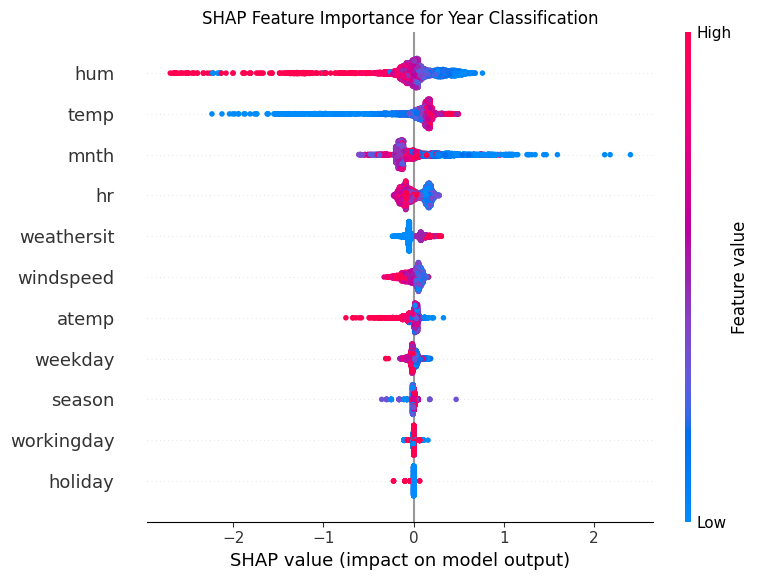

In [15]:
def create_classification_dataset(
    X: pd.DataFrame, features: list[str]
) -> tuple[pd.DataFrame, pd.Series, list[str]]:
    """
    Prepare the dataset for year classification.

    Args:
        X: Feature matrix.
        features: Names of the columns in X.

    Returns:
        A tuple of (feature matrix without 'yr', target labels 'yr', list of
        feature names without 'yr').
    """
    # Extract the target feature (yr)
    y = X['yr'].astype(int)

    # Remove yr from the features
    features_for_classification = [f for f in features if f != 'yr']
    X_class = X[features_for_classification]

    return X_class, y, features_for_classification

def train_year_classifier(
    X: pd.DataFrame, features: list[str]
) -> tuple[Pipeline, list[str]]:
    """
    Train an XGBoost classifier to predict the year (yr) from the other
    features, then use SHAP to identify which features are most predictive
    of the year.

    Args:
        X: Feature matrix.
        features: Names of the columns in X.

    Returns:
        A tuple of (fitted Pipeline, list of feature names used for
        classification).
    """
    # Prepare the dataset
    X_class, y, features_class = create_classification_dataset(X, features)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_class, y, test_size=0.2, random_state=42
    )

    # Build the pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgboost', xgb.XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        ))
    ])

    # Train the model
    print("Training the classifier...")
    pipeline.fit(X_train, y_train)

    # Evaluate the model
    y_pred = pipeline.predict(X_test)

    print("\nModel evaluation:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=['2011', '2012']))

    # SHAP Analysis
    print("\nComputing SHAP values...")
    # Extract the model from the pipeline
    model = pipeline.named_steps['xgboost']
    # Transform the data
    X_transformed = pipeline.named_steps['scaler'].transform(X_test)
    X_test_transformed = pd.DataFrame(X_transformed, columns=features_class)

    # Compute SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_transformed)

    # Plot SHAP summary
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values,
        X_test_transformed,
        feature_names=features_class,
        show=False
    )
    plt.title("SHAP Feature Importance for Year Classification")
    plt.tight_layout()
    plt.show()

    return pipeline, features_class

pipeline, features_class = train_year_classifier(X, features)